In [1]:
import os

os.chdir('../')

[1.         0.6333792  0.27595413 0.        ]
[ 1.00000000e+00  5.88565151e-01  2.84102241e-01 -5.96046448e-08]
tensor([1.0000e+00, 5.8857e-01, 2.8410e-01, 1.1102e-16], dtype=torch.float64)
[ 1.0000000e+00  6.6112614e-01  4.8506355e-01  3.5041755e-01
  1.7591596e-01 -1.1920929e-07]


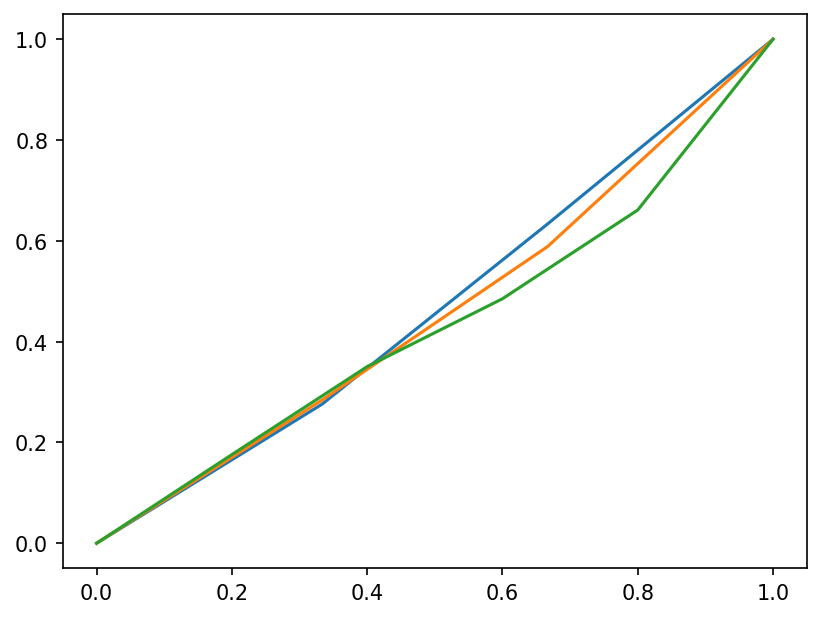

In [61]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def get_timesteps(log_deltas, t0=1.0, tM=0.0):
    deltas = F.softmax(log_deltas, dim=0)          # (S,)
    c = torch.cumsum(deltas, dim=0)                # (S,)
    timesteps = torch.cat([t0*torch.ones(1, device=log_deltas.device), t0 + (tM - t0) * c], dim=0)
    return timesteps

def invert_timesteps(timesteps, t0=1.0, tM=0.0, eps=1e-12):
    # c_i = (t_i - t0) / (tM - t0)
    c = (timesteps[1:] - t0) / (tM - t0)       # (S,)

    # deltas_1 = c_1,  deltas_i = c_i - c_{i-1}
    deltas = torch.cat([c[:1], c[1:] - c[:-1]])  # (S,)

    deltas = deltas.clamp_min(eps)
    deltas = deltas / deltas.sum()

    log_deltas = deltas.log()
    return log_deltas    

def avg_pwlin(x, x1, y1, x2, y2):
    x = np.asarray(x)
    f1 = np.interp(x, x1[::-1], y1[::-1])
    f2 = np.interp(x, x2[::-1], y2[::-1])
    return (f1 + f2) / 2    

log_deltas1 = torch.load('logs/dit/mobile/s3/step_00020000.pt')['solver_state_dict']['log_deltas']
log_deltas2 = torch.load('logs/dit/mobile/s5/step_00020000.pt')['solver_state_dict']['log_deltas']

timesteps1 = get_timesteps(log_deltas1).data.cpu().numpy()
inputs1 = np.linspace(1, 0, len(timesteps1))
timesteps2 = get_timesteps(log_deltas2).data.cpu().numpy()
inputs2 = np.linspace(1, 0, len(timesteps2))
inputs3 = np.linspace(1, 0, 4)
timesteps3 = avg_pwlin(inputs3, inputs1, timesteps1, inputs2, timesteps2)

log_deltas3 = invert_timesteps(torch.tensor(timesteps3))
print(timesteps1)
print(timesteps3)
print(get_timesteps(log_deltas3))
print(timesteps2)

plt.plot(inputs1, timesteps1)
plt.plot(inputs3, timesteps3)
plt.plot(inputs2, timesteps2)
plt.show()


In [ ]:
# log_deltas2 = torch.load('logs/dit/mobile/s5/step_00020000.pt')['solver_state_dict']['log_deltas']
# timesteps2 = get_timesteps(log_deltas2, 1, 0)
# print(timesteps2)

# data = torch.load('logs/dit/mobile/s5/step_00020000.pt')
# timestep2 = get_timesteps(data).cpu().numpy()
# input2 = np.linspace(1, 0, len(timestep2))
# plt.plot(input2, timestep2)

# import numpy as np

# def avg_pwlin(x, x1, y1, x2, y2):
#     x = np.asarray(x)
#     f1 = np.interp(x, x1[::-1], y1[::-1])
#     f2 = np.interp(x, x2[::-1], y2[::-1])
#     return (f1 + f2) / 2

# input3 = np.linspace(1, 0, 4)
# timestep3 = avg_pwlin(input3, input1, timestep1, input2, timestep2)
# plt.plot(input3, timestep3)

In [ ]:
import torch
import torch.nn.functional as F

def _resize_weight(weight, n_steps):
    """
    weight: (S, 2, 5)
    n_steps: 목표 step 수
    return: (n_steps, 2, 5)
    """
    S, C1, C2 = weight.shape          # C1=2, C2=5
    x = weight.reshape(S, -1).T       # (C, S)
    x = x.unsqueeze(0)                # (1, C, S)
    x = F.interpolate(x, size=n_steps, mode='linear', align_corners=True)
    x = x.squeeze(0).T.reshape(n_steps, C1, C2)
    return x

def get_interpolated_weight(n_steps, weight1, weight2):
    w1 = _resize_weight(weight1, n_steps)   # s3 → n_steps
    w2 = _resize_weight(weight2, n_steps)   # s5 → n_steps
    return 0.5 * (w1 + w2)                  # 두 테이블 평균


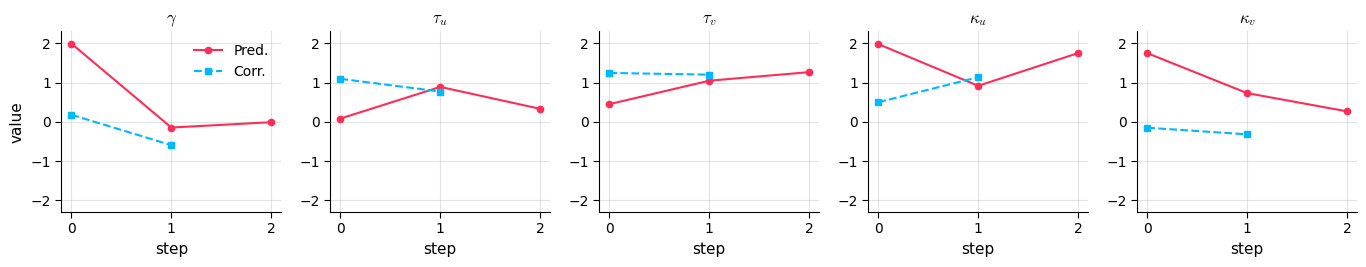

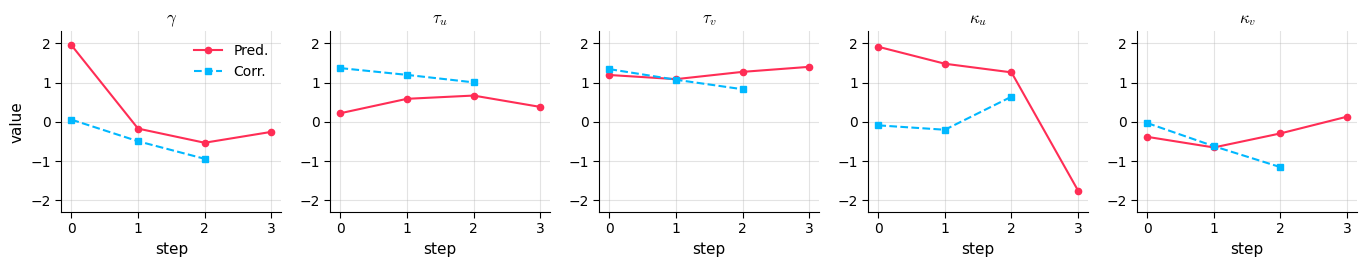

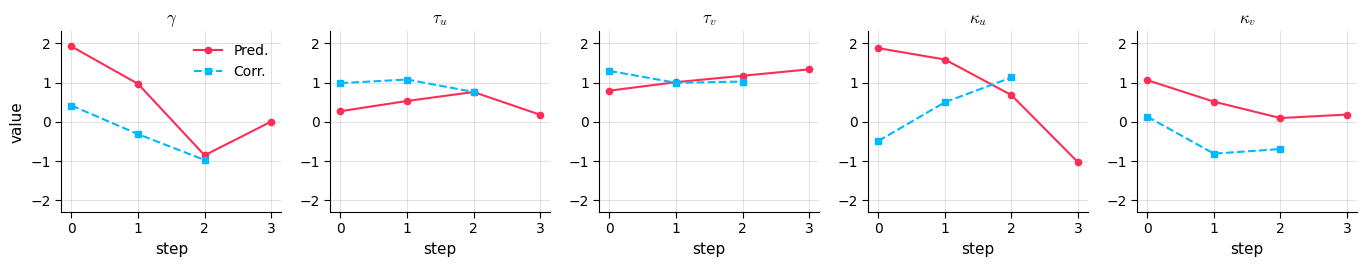

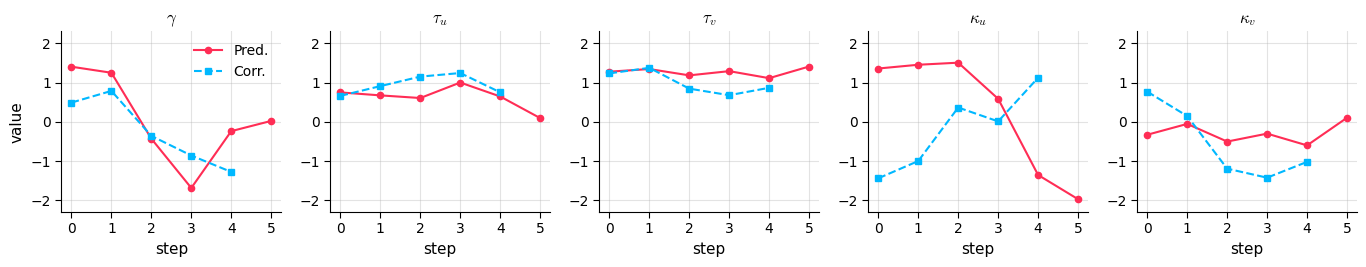

In [27]:
import numpy as np
import scipy 

# Minimal change: keep your plotting logic identical, only loop over s3/s5/s7/s9.
import torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ---------- Palettes & colors (unchanged) ----------
PALETTES = [
    ["#FF2D55", "#00B8FF", "#00E676"],
    ["#1f77b4", "#ff7f0e", "#2ca02c"],  # Classic Blue–Orange–Green
    ["#d62728", "#1f77b4", "#7f7f7f"],  # Muted Red–Blue–Gray
    ["#4c78a8", "#f58518", "#54a24b"],  # Vega-Altair Set
    ["#2b83ba", "#abdda4", "#fdae61"],  # Nature Inspired
    ["#e69f00", "#56b4e9", "#009e73"],  # CUD (color-blind friendly)
    ["#377eb8", "#e41a1c", "#4d4d4d"],  # Cool–Warm–Neutral
    ["#8c510a", "#01665e", "#f5f5f5"],  # Earth Tone
    ["#e41a1c", "#377eb8", "#4daf4a"],  # Bold & Bright
    ["#984ea3", "#ff7f00", "#66a61e"],  # Dark Pastel
    ["#000000", "#7f7f7f", "#e6e6e6"],  # Grayscale Emphasis
]
PALETTE_INDEX = 0
PRED_COLOR = PALETTES[PALETTE_INDEX][0]
CORR_COLOR = PALETTES[PALETTE_INDEX][1]

# ---------- Style (ICLR-ready, unchanged) ----------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,                    # 본문 크기
    "axes.titlesize": 12,               # 서브플롯 제목
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "grid.alpha": 0.35,
    "mathtext.fontset": "cm",           # Computer Modern 수학 폰트
})

# (index, title, transform, refline) — unchanged
params = [
    (0, r'$\gamma$',  lambda a: np.tanh(a)*2.,          0.0),
    (1, r'$\tau_u$',  lambda a: scipy.special.softplus(1.0 + a),    1.0),
    (2, r'$\tau_v$',  lambda a: scipy.special.softplus(1.0 + a),    1.0),
    (3, r'$\kappa_u$',lambda a: np.tanh(a)*2,          0.0),
    (4, r'$\kappa_v$',lambda a: np.tanh(a)*2,          0.0),
]
lw = 1.5
ms = 4.5

def render(weight):
    tab = weight.data.cpu().float().numpy()  # [S,2,P]
    x   = np.arange(tab.shape[0])  # 0..S-1 (step index)

    fig, ax = plt.subplots(1, 5, figsize=(13.8, 2.8), sharex=True, dpi=100)  # unchanged

    for k, (idx, title, f, refline) in enumerate(params):
        pred = f(tab[:, 0, idx])
        corr_full = f(tab[:, 1, idx])

        # corr는 한 칸 당겨 정렬(corr[1:]) + 마지막 step은 아예 그리지 않음 — unchanged
        corr_shift = corr_full[1:]      # 길이: S-1
        x_corr     = x[:-1]             # 길이: S-1

        # 데이터 기반 여백 있는 y-범위 (마지막 corr 점 제외한 값으로 계산) — unchanged
        y = np.concatenate([pred, corr_shift])
        ypad = 0.08 * (np.nanmax(y) - np.nanmin(y) + 1e-9)
        ymin, ymax = np.nanmin(y) - ypad, np.nanmax(y) + ypad

        ax[k].plot(x,       pred, '-',  marker='o', ms=ms, lw=lw, label='Pred.', color=PRED_COLOR)
        ax[k].plot(x_corr,  corr_shift, '--', marker='s', ms=ms, lw=lw, label='Corr.', color=CORR_COLOR)

        ax[k].set_title(title, pad=6)
        ax[k].set_ylim(-2.3, 2.3)  # unchanged fixed range
        ax[k].set_xlabel('step')
        ax[k].xaxis.set_major_locator(MaxNLocator(integer=True))
        ax[k].grid(True, which='major')
        ax[k].tick_params(direction='out', length=4, width=0.8)
        for spine in ['top', 'right']:
            ax[k].spines[spine].set_visible(False)

    # 왼쪽 첫 축에만 y라벨 — unchanged
    ax[0].set_ylabel('value')

    # 범례: 첫 축에만, 프레임 제거 — unchanged
    ax[0].legend(loc='best', frameon=False, ncols=1)

    fig.tight_layout(w_pad=1.2)
    plt.show()

weight1 = torch.load('logs/dit/mobile/s3/step_00020000.pt')['solver_state_dict']['param_extractor.table']
render(weight1)
weight2 = torch.load('logs/dit/mobile/s6/step_00020000.pt')['solver_state_dict']['param_extractor.table']
weight3 = torch.load('logs/dit/mobile/s4/step_00020000.pt')['solver_state_dict']['param_extractor.table']
render(weight3)
weight4 = get_interpolated_weight(4, weight1, weight2)  # (4, 2, 5)    
render(weight4)
render(weight2)
